# Twinkle — MP2 Project Notebook

**HCDE 530 · Mini Project 2**

| | |
|---|---|
| **Live site** | https://twinkle.ltd |
| **Repo** | github.com/rachitsinghi/hcde530/MP2 |
| **Data** | HYG v4.2 → `public/stars_visible.csv` (8,834 naked-eye stars) |

Twinkle is an interactive star map that lets anyone invent a constellation, map it onto real catalog stars, name it with AI, and view it in 2D, 3D, or mobile AR. This notebook documents the project and explores the underlying star data that powers the app.

## What did I build?

Twinkle is a browser-based creative instrument — not a dashboard. Users can:

1. **Draw** a constellation on a dot-grid sketch pad (straight-line segments)
2. **IMAGINE** a shape by typing a description (Iconify API searches 275,000+ icons)
3. **Draw with finger** using MediaPipe hand tracking + laptop camera
4. **MAP TO STARS** — each sketch vertex snaps to the nearest HYG catalog star
5. **GET NAME** — Groq (`llama-3.1-8b-instant`) generates a mythological-sounding name
6. **Toggle 2D / 3D** — flat sky projection vs. real parsecs in Cartesian space
7. **DOWNLOAD PNG** or **VIEW IN AR** on mobile (compass + rear camera)

It extends **MP1**, which used K-Means clustering on the same HYG dataset to ask whether user-defined shapes can meaningfully attach to real stars.

## Setup

Load the filtered star catalog that the React app serves from `public/stars_visible.csv`. The preprocessing script lives at `Week 8/prepare_stars.py` in the parent repo.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / "public" / "stars_visible.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} stars from {DATA_PATH.name}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")

/Users/rachit/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/b_/wtm8llxj43v_32ysfm0whzyr0000gn/T/matplotlib-bjsi7sm5 because there was an issue with the default path (/Users/rachit/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Loaded 8,834 stars from stars_visible.csv
Columns (12): ['id', 'ra_deg', 'dec', 'mag', 'ci', 'spect', 'lum', 'proper', 'dist', 'x', 'y', 'z']


## Dataset overview

The HYG v4.2 catalog composites Hipparcos, Yale Bright Star, and Gliese-Jahreiß data. `prepare_stars.py` filters to **apparent magnitude < 6.5** (human naked-eye limit) and **distance > 0.01 pc**, converts RA from hours to degrees, and precomputes Cartesian `x/y/z` in parsecs for the Three.js 3D view.

In [4]:
df.head(10)

,id,ra_deg,dec,mag,ci,spect,lum,proper,dist,x,y,z
0,25,0.0795,-44.2906,6.28,0.763,G3IV,17.7337,NaN,81.3670,58.2431,0.0808,-56.8184
1,34,0.0996,26.9181,6.43,0.514,F7.5IV-V,12.9897,NaN,74.6269,66.5413,0.1156,33.7848
2,43,0.1289,59.5597,6.18,1.032,G9III-IV,54.5507,NaN,136.2398,69.0244,0.1553,117.4601
3,50,0.1430,-53.0977,6.49,0.616,G1IV,7.7983,NaN,59.4177,35.6774,0.0890,-47.5140
4,63,0.1818,45.2533,6.36,-0.047,B9p SiEu,87.9023,NaN,187.9699,132.3251,0.4198,133.5012
5,88,0.2691,-48.8099,5.71,0.911,G8III,149.6925,NaN,181.8182,119.7368,0.5624,-136.8234
6,106,0.3302,49.9816,6.22,0.970,G7II-III,112.8236,NaN,199.6008,128.3480,0.7397,152.8618
7,107,0.3338,-50.3374,5.53,1.615,M2III,148.0471,NaN,166.3894,106.1989,0.6188,-128.0892
8,122,0.3992,-77.0657,4.78,1.254,K2III,47.2933,NaN,66.5779,14.9020,0.1038,-64.8886
9,124,0.4042,61.2228,5.58,0.407,F0III,4541.5071,NaN,943.3962,454.1443,3.2041,826.8852


In [5]:
summary = pd.DataFrame({
    "metric": [
        "Total stars",
        "Named stars (proper)",
        "Magnitude range",
        "Distance range (pc)",
        "Color index range",
        "File size (KB)",
    ],
    "value": [
        f"{len(df):,}",
        f"{(df['proper'].fillna('').str.strip() != '').sum():,}",
        f"{df['mag'].min():.2f} to {df['mag'].max():.2f}",
        f"{df['dist'].min():.2f} to {df['dist'].max():.0f}",
        f"{df['ci'].min():.2f} to {df['ci'].max():.2f}",
        f"{DATA_PATH.stat().st_size / 1024:.0f}",
    ],
})
summary

,metric,value
0,Total stars,"8,834"
1,Named stars (proper),392
2,Magnitude range,-1.44 to 6.49
3,Distance range (pc),1.32 to 100000
4,Color index range,-0.31 to 3.33
5,File size (KB),730


## C6 — Visual encoding: magnitude → size

In `StarMap.tsx`, star radius uses a **non-linear power scaling** so bright stars dominate visually, matching human night-sky perception:

```js
Math.max(1, Math.pow(6.5 - mag, 1.5) * 2.5)
```

Sirius at mag −1.44 should render dramatically larger than a star at mag 5.0.

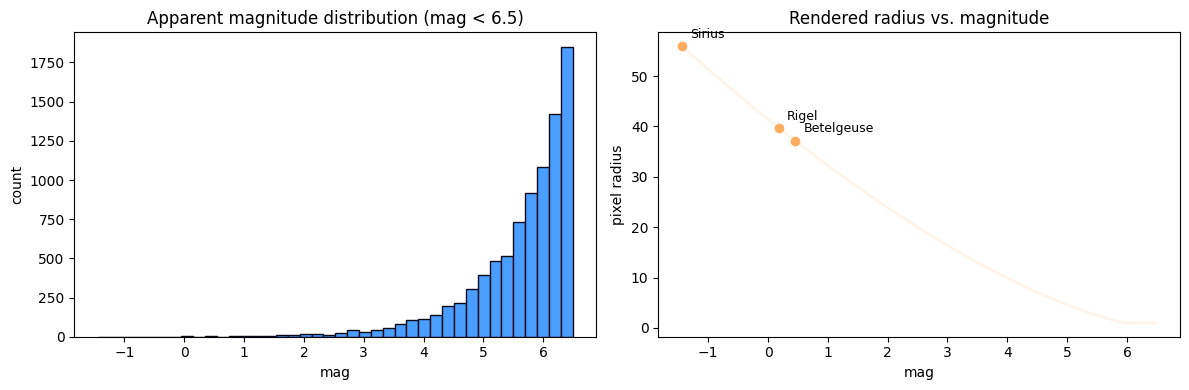

In [6]:
def star_radius(mag: float) -> float:
    """Same formula as StarMap.tsx (2D glow uses a related linear variant)."""
    return max(1.0, (6.5 - mag) ** 1.5 * 2.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["mag"], bins=40, color="#4a9eff", edgecolor="#0a0a1a")
axes[0].set_title("Apparent magnitude distribution (mag < 6.5)")
axes[0].set_xlabel("mag")
axes[0].set_ylabel("count")

mag_range = np.linspace(df["mag"].min(), df["mag"].max(), 200)
axes[1].plot(mag_range, [star_radius(m) for m in mag_range], color="#fff4ea", linewidth=2)
axes[1].scatter(df.loc[df["proper"].isin(["Sirius", "Betelgeuse", "Rigel"]), "mag"],
                df.loc[df["proper"].isin(["Sirius", "Betelgeuse", "Rigel"]), "mag"].map(star_radius),
                c="#ffad60", zorder=5)
for _, row in df[df["proper"].isin(["Sirius", "Betelgeuse", "Rigel"])].iterrows():
    axes[1].annotate(row["proper"], (row["mag"], star_radius(row["mag"])), textcoords="offset points", xytext=(6, 6), fontsize=9)
axes[1].set_title("Rendered radius vs. magnitude")
axes[1].set_xlabel("mag")
axes[1].set_ylabel("pixel radius")

plt.tight_layout()
plt.show()

## C6 — Visual encoding: B-V color index → star color

The `ci` field (B-V color index) maps to discrete hex colors in the app:

| B-V (`ci`) | Color | Stellar type |
|---|---|---|
| < −0.2 | `#9bb0ff` | hot blue (O-type) |
| 0.0 – 0.3 | `#cad7ff` | white (A-type) |
| 0.6 – 1.0 | `#fff4ea` | yellow (G-type) |
| > 1.5 | `#ffad60` | red (M-type) |

Betelgeuse (ci ≈ 1.5) appears orange-red; Rigel (ci ≈ −0.03) appears blue-white — without the user ever seeing a legend.

In [7]:
def color_for_ci(ci: float) -> str:
    if ci < -0.2:
        return "#9bb0ff"
    if ci < 0.3:
        return "#cad7ff"
    if ci < 1.0:
        return "#fff4ea"
    if ci < 1.5:
        return "#ffeed8"
    return "#ffad60"

showcase = df[df["proper"].isin(["Sirius", "Betelgeuse", "Rigel", "Vega", "Polaris"])].copy()
showcase["render_color"] = showcase["ci"].map(color_for_ci)
showcase[["proper", "mag", "ci", "spect", "dist", "render_color"]]

,proper,mag,ci,spect,dist,render_color
762,Polaris,1.97,0.636,F7:Ib-IIv SB,132.6260,#fff4ea
1707,Rigel,0.18,-0.030,B8Ia,264.5503,#cad7ff
2045,Betelgeuse,0.45,1.500,M2Ib,152.6718,#ffad60
2423,Sirius,-1.44,0.009,A0m...,2.6371,#cad7ff
6792,Vega,0.03,-0.001,A0Vvar,7.6787,#cad7ff


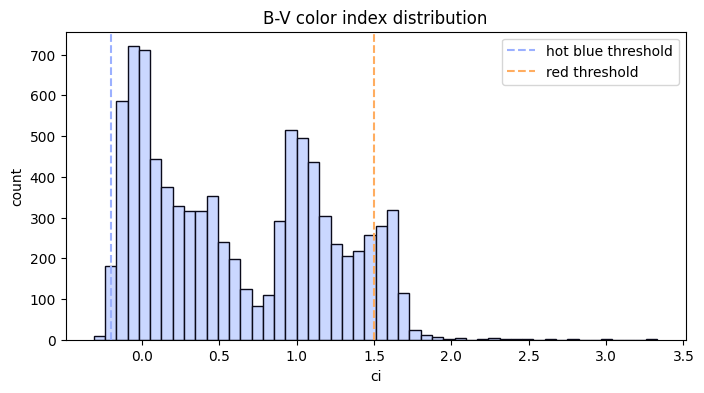

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["ci"], bins=50, color="#cad7ff", edgecolor="#0a0a1a")
ax.axvline(-0.2, color="#9bb0ff", linestyle="--", label="hot blue threshold")
ax.axvline(1.5, color="#ffad60", linestyle="--", label="red threshold")
ax.set_title("B-V color index distribution")
ax.set_xlabel("ci")
ax.set_ylabel("count")
ax.legend()
plt.show()

## C6 — 3D view: distance reveals constellation illusion

Precomputed coordinates use spherical → Cartesian conversion:

```
x = dist * cos(dec_rad) * cos(ra_rad)
y = dist * cos(dec_rad) * sin(ra_rad)
z = dist * sin(dec_rad)
```

In 2D, constellation lines look connected. In 3D (`StarMap3D.tsx`), the same lines stretch apart because anchor stars sit at wildly different distances — a finding first documented in MP1 (Felis cat: 49–411 parsecs apart).

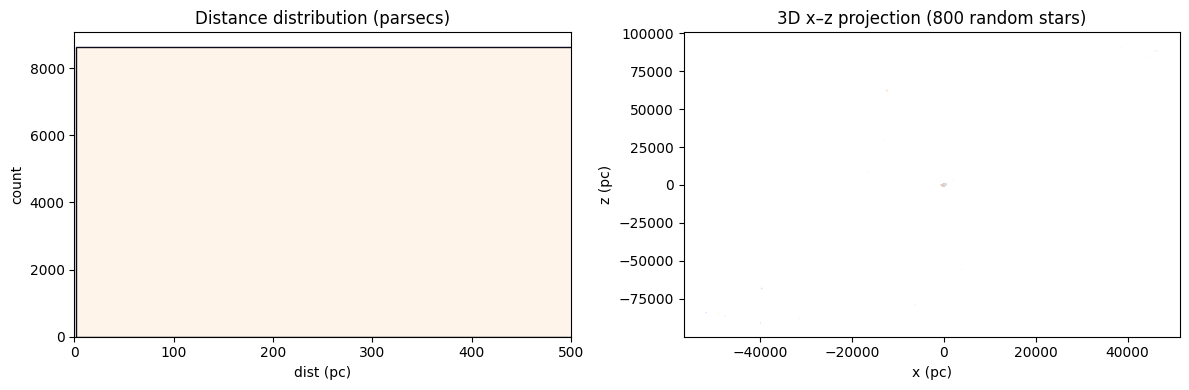

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["dist"], bins=50, color="#fff4ea", edgecolor="#0a0a1a")
axes[0].set_title("Distance distribution (parsecs)")
axes[0].set_xlabel("dist (pc)")
axes[0].set_ylabel("count")
axes[0].set_xlim(0, 500)

sample = df.sample(800, random_state=42)
axes[1].scatter(sample["x"], sample["z"], s=sample["mag"].rsub(6.5).clip(0.2, 5), c=sample["ci"].map(color_for_ci), alpha=0.7, edgecolors="none")
axes[1].set_title("3D x–z projection (800 random stars)")
axes[1].set_xlabel("x (pc)")
axes[1].set_ylabel("z (pc)")

plt.tight_layout()
plt.show()

## Brightest named stars in the catalog

These are the stars users are most likely to recognise when a sketch snaps to the map.

In [10]:
named = df[df["proper"].fillna("").str.strip() != ""].copy()
top = named.nsmallest(15, "mag")[["proper", "mag", "ci", "spect", "dist", "ra_deg", "dec"]]
top

,proper,mag,ci,spect,dist,ra_deg,dec
2423,Sirius,-1.44,0.009,A0m...,2.6371,101.2872,-16.7161
2254,Canopus,-0.62,0.164,F0Ib,94.7867,95.9879,-52.6957
5184,Arcturus,-0.05,1.239,K2IIIp,11.2575,213.9154,19.1824
5315,Rigil Kentaurus,-0.01,0.710,G2V,1.3248,219.9115,-60.8340
6792,Vega,0.03,-0.001,A0Vvar,7.6787,279.2346,38.7837
1722,Capella,0.08,0.795,M1: comp,13.1234,79.1723,45.9980
1707,Rigel,0.18,-0.030,B8Ia,264.5503,78.6345,-8.2016
2845,Procyon,0.40,0.432,F5IV-V,3.5142,114.8255,5.2250
487,Achernar,0.45,-0.158,B3Vp,42.7533,24.4283,-57.2368
2045,Betelgeuse,0.45,1.500,M2Ib,152.6718,88.7929,7.4071


## Snap-to-star algorithm (simplified)

When a user clicks **MAP TO STARS**, `StarMap.tsx` maps each sketch vertex to the nearest catalog star in RA/Dec space, preferring **brighter stars** (lower `mag`) when distances tie. This notebook demo uses a tiny subset to illustrate the idea.

In [11]:
def snap_vertices(vertices_ra_dec, stars_df):
    """Greedy nearest-neighbor snap with brightness tie-break (simplified)."""
    used = set()
    snapped = []
    for target_ra, target_dec in vertices_ra_dec:
        best = None
        best_d = float("inf")
        for _, s in stars_df.iterrows():
            if s["id"] in used:
                continue
            d = np.hypot(s["ra_deg"] - target_ra, s["dec"] - target_dec)
            if d < best_d - 0.5:
                best, best_d = s, d
            elif d < best_d + 0.5 and (best is None or s["mag"] < best["mag"]):
                best, best_d = s, min(best_d, d)
        if best is not None:
            used.add(best["id"])
            snapped.append(best)
    return pd.DataFrame(snapped)

# Orion-region subset + three fake sketch vertices
orion = df[(df["ra_deg"] > 70) & (df["ra_deg"] < 95) & (df["dec"] > -15) & (df["dec"] < 15)]
vertices = [(82, 5), (86, 0), (90, -5)]
snapped = snap_vertices(vertices, orion)
snapped[["proper", "mag", "ra_deg", "dec", "dist"]].fillna({"proper": "(unnamed)"})

,proper,mag,ra_deg,dec,dist
1794,Bellatrix,1.64,81.2828,6.3497,77.3994
1939,(unnamed),5.93,85.2733,0.3378,47.9386
2047,(unnamed),5.87,88.8757,-4.6165,96.9932


## Tech stack

| Layer | Technology |
|---|---|
| Frontend | React 19, TanStack Start, Vite 7, HTML5 Canvas, Three.js |
| UI | Tailwind CSS 4, shadcn/ui |
| Hand tracking | Google MediaPipe Hand Landmarker (CDN) |
| CSV loading | PapaParse |
| Icon shapes | Iconify API (275,000+ icons) |
| AI naming | Groq API via `/api/name-constellation` server route |
| Hosting | Lovable, Cloudflare Workers, custom domain (twinkle.ltd) |
| Data prep | Python — `Week 8/prepare_stars.py` |

### Key source files

| File | Role |
|---|---|
| `src/components/StarMap.tsx` | 2D Canvas rendering, snap-to-star, CSV load |
| `src/components/StarMap3D.tsx` | Three.js 3D view with real parsecs |
| `src/components/SketchHUD.tsx` | Sketch pad, IMAGINE, finger drawing, naming UI |
| `src/components/ARSkyView.tsx` | Mobile AR overlay (compass + camera) |
| `src/routes/api/name-constellation.ts` | Groq naming API (key stays server-side) |
| `public/stars_visible.csv` | Filtered HYG data served as static asset |
| `wrangler.jsonc` | Cloudflare Workers deployment config |

## C7 — Critical evaluation highlights

Three moments where AI output was caught and corrected before reaching users:

1. **Coordinate generation failure** — LLMs cannot reliably generate geometry. Fix: Iconify SVG paths parsed in `SketchHUD.tsx` (M/L commands only).
2. **Quick Draw CORS failure** — Google's ndjson bucket blocked browser fetch; edge-function workaround was slow (2–8s). Fix: Iconify (<500ms).
3. **Finger tracking calibration** — fixed 15px/35px thresholds were twitchy. Fix: palm-size calibration: `adjusted_threshold = 55 * (calibrated_palm_size / 80)`.

**Lesson:** match the tool to the question. AI is good at language and retrieval; it is not good at spatial coordinate generation.

## C8 — Deployment & scope decisions

- **Deployed** at https://twinkle.ltd with full user flow: draw → map → name → download → AR (mobile)
- **Groq API key** hidden behind TanStack Start server route on Cloudflare Workers
- **Supabase persistence** cut from MP2a plan — shipped as a creation tool (PNG download), not a social registry
- **AR limitation:** compass-only overlay is directionally approximate; GPS + sidereal time would make it astronomically accurate

### Data pipeline

```bash
# From hcde530 repo root
pip install pandas numpy   # only needed if extending prepare_stars.py
python3 "Week 8/prepare_stars.py"
# Copy Week 8/stars_visible.csv → MP2/public/
```

## Reflection summary

**What did I build?** A browser-based creative instrument extending MP1's star-cluster analysis into an interactive constellation maker.

**What decisions did I make?** Lovable for UI speed; Groq for free-tier naming; Canvas over SVG; Iconify over LLM coordinates; cut Supabase.

**What would I do differently?** Define IMAGINE as icon-search on day one; add `navigator.geolocation` to `ARSkyView.tsx`.

**What does this demonstrate?** C6 in visual encodings; C7 in AI evaluation; C8 in end-to-end deployment. Competencies are embedded in what shipped.

---

See also: `README.md` (user docs), `mp2.md` (competency claims), `reflection.md` (500-word reflection).